In [8]:
import os
import sys
import time

import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import pandas as pd
import seaborn as sns

from PIL import Image



In [4]:
df = pd.read_csv('Dataset/train.csv')
print(df.shape)
df.head()

(23850, 4)


,image_id,image_path,writer_id,pen_id
0,4,images/00004.png,W27,8
1,5,images/00005.png,W17,1
2,7,images/00007.png,W01,8
3,8,images/00008.png,W17,5
4,9,images/00009.png,W24,4


Dataset/images/


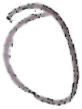

In [ ]:
path_variable = 'Dataset/images/'
print(path_variable)
img4 = Image.open(path_variable + "00004.png")
img5 = Image.open(path_variable + "00004.png")
img4

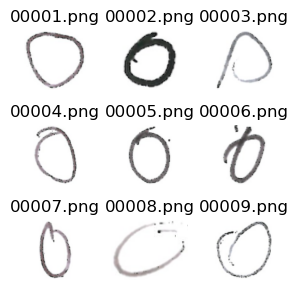

In [16]:
image_files = sorted([f for f in os.listdir(path_variable) if f.endswith(".png")])
image_files = image_files[:9]
fig, axes = plt.subplots(3, 3, figsize=(3, 3))

for ax, image_file in zip(axes.ravel(), image_files):
    img = Image.open(os.path.join(path_variable, image_file))
    ax.imshow(img)
    ax.set_title(image_file)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# TBD für EDA:
# nach WriterID gruppieren und die Anzahl der Bilder pro WriterID visualisieren
# nach PenType gruppieren und die Anzahl der Bilder pro PenType visualisieren 
# haben alle WriterIDs die gleiche Anzahl an Bildern? (ggf. mit einem Boxplot visualisieren)


# TBD für Modellentscheidung:
# Wenn EDA zeigt, dass lokale Strichtextur dominiert -> CNN sehr sinnvoll
# Wenn EDA zeigt, dass globale Formabweichungen stark sind -> globale Shape-Features ergänzen
# Wenn EDA zeigt, dass Pen/Scan stark dominiert -> härtere Normalisierung und bessere Validation
# Wenn EDA zeigt, dass Writer intern sehr konsistent sind -> Metric Learning lohnt sich besonders
# Writerentscheidung mittels Radius / Größe des Kreises, Geschlossenheit, Krümmungsverlauf, Druck-/Tintenvariation --> CNNs
# 2D-Projektion einfacher Features oder vortrainierter Embeddings mittels PCA/t-SNE/UMAP visualisieren, um zu sehen, ob WriterIDs Cluster bilden oder ob es starke Überlappungen gibt


# Offene Fragen:
# Pro Writer zu wenige Bilder -> Datenaugmentation oder Few-Shot Learning nötig oder GAN-Bilder erstellen oder Up/Downsampling im Training?
# Bilder gleich groß?
# Wie stark variiert die Linienstärke?
# Ist der Kreis immer zentriert?
# Gibt es starke Unterschiede in Helligkeit/Kontrast? -> Histogramm stretching oder CLAHE als Vorverarbeitung?
# - Verteilung von Bildhöhe/Bildbreite, Verteilung von mittlerer Helligkeit, Verteilung von Kontrast / Standardabweichung der Pixel
# - ein Grid mit z. B. 50 zufälligen Bildern

In [ ]:
# neu strukturiert:

# Datensatz 
# - Klassenverteilung 
# - Sample-Zahl 
# - Splits
# - mögliche Leaks

# Bild
# - Auflösung
# - Helligkeit
# - Kontrast
# - Rand
# - Scanartefakte
# - Dicke / Position des Kreises

# Identitätssignal
# - intra-writer Konsistenz
# - inter-writer Unterschiede
# - pen-/scanbedingte Störfaktoren
# - unknown-Writer-Simulation